In [1]:
from misc.dataset import get_data
from misc.helpers import normalizeRNA
from models.cncvae import CNCVAE
from models.dec import DEC
from models.metrics import calculate_metrics

data = get_data()
x_num = normalizeRNA(data['rnanp'])   # RNA-seq CPM, min-max scaled
x_bin = data['clin']                  # binary clinical/genotype dummies
print(x_num.shape, x_bin.shape, data['label_classes'])

ae = CNCVAE(input_size=x_num.shape[1] + x_bin.shape[1], ls=8)
ae.build_model()
ae.train(x_num, x_bin)

dec = DEC(ae, n_clusters=2)
y_pred, y_proba, centroids, z = dec.fit(x_num, x_bin, y=data['y'])

acc, ari, nmi = calculate_metrics(data['y'], y_pred)
print('acc={:.3f}  ari={:.3f}  nmi={:.3f}'.format(acc, ari, nmi))

(166, 81) (166, 19) ['MGS1' 'MGS4']
Epoch 7/150 - loss: 0.6935
Epoch 14/150 - loss: 0.5758
Epoch 21/150 - loss: 0.5366
Epoch 28/150 - loss: 0.5087
Epoch 35/150 - loss: 0.4965
Epoch 42/150 - loss: 0.4988
Epoch 49/150 - loss: 0.4969
Epoch 56/150 - loss: 0.4837
Epoch 63/150 - loss: 0.4968
Epoch 70/150 - loss: 0.4880
Epoch 77/150 - loss: 0.4807
Epoch 84/150 - loss: 0.4895
Epoch 91/150 - loss: 0.4862
Epoch 98/150 - loss: 0.4761
Epoch 105/150 - loss: 0.4778
Epoch 112/150 - loss: 0.4835
Epoch 119/150 - loss: 0.4875
Epoch 126/150 - loss: 0.4823
Epoch 133/150 - loss: 0.4761
Epoch 140/150 - loss: 0.4788
Epoch 147/150 - loss: 0.4735
Iter 0: acc = 0.67470, nmi = 0.10532, ari = 0.06622 ; loss=0.00000
Iter 50: acc = 0.67470, nmi = 0.10532, ari = 0.06622 ; loss=0.00000
delta_label 0.0 < tol 0.01
performed 50 iterations.
Reached tolerance threshold. Stopping training.
Final: acc = 0.67470, nmi = 0.10532, ari = 0.06622 ; loss=0.00000
acc=0.675  ari=0.066  nmi=0.105


In [ ]:
import os
import pandas as pd

run_dir = 'results/manual'
os.makedirs(run_dir, exist_ok=True)

ae.save_encoder(os.path.join(run_dir, 'encoder_cncvae.pt'))

emb = pd.DataFrame({'sample_id': data['sample_id']})
for j in range(z.shape[1]):
    emb['z{}'.format(j)] = z[:, j]
emb['mgs_level'] = data['label_classes'][data['y']]
emb.to_csv(os.path.join(run_dir, 'cncdec_latent_embedding.csv'), index=False)

import numpy as np
np.savez(os.path.join(run_dir, 'mgs_level.npz'),
         z=z, y_pred=y_pred, y_proba=y_proba, centroids=centroids,
         y=data['y'], sample_id=data['sample_id'], classes=data['label_classes'])
print('Saved to', run_dir)

Saved to results/manual_run_2


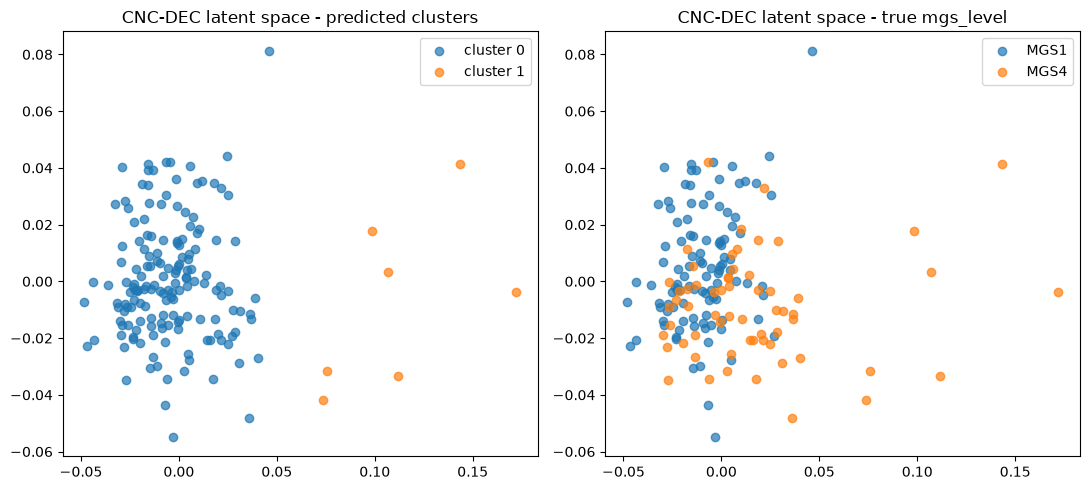

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

proj = PCA(n_components=2, random_state=5192).fit_transform(z)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for c in np.unique(y_pred):
    mask = y_pred == c
    axes[0].scatter(proj[mask, 0], proj[mask, 1], label=f'cluster {c}', alpha=0.7)
axes[0].set_title('CNC-DEC latent space - predicted clusters')
axes[0].legend()

for c, name in enumerate(data['label_classes']):
    mask = data['y'] == c
    axes[1].scatter(proj[mask, 0], proj[mask, 1], label=name, alpha=0.7)
axes[1].set_title('CNC-DEC latent space - true mgs_level')
axes[1].legend()
plt.tight_layout()
plt.show()

mgs_level  MGS1  MGS4
cluster              
0            14    37
1            91    24


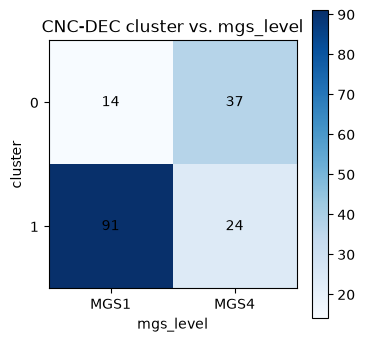

In [6]:
ct = pd.crosstab(pd.Series(y_pred, name='cluster'),
                 pd.Series(data['label_classes'][data['y']], name='mgs_level'))
print(ct)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(ct.values, cmap='Blues')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
ax.set_xlabel('mgs_level'); ax.set_ylabel('cluster')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha='center', va='center')
plt.colorbar(im)
plt.title('CNC-DEC cluster vs. mgs_level')
plt.show()

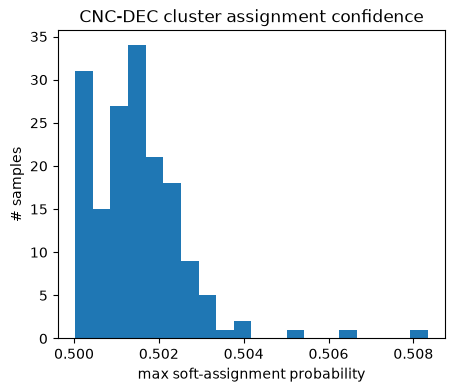

In [7]:
plt.figure(figsize=(5, 4))
plt.hist(y_proba.max(axis=1), bins=20)
plt.xlabel('max soft-assignment probability')
plt.ylabel('# samples')
plt.title('CNC-DEC cluster assignment confidence')
plt.show()

In [1]:
from misc.dataset import get_data
from misc.helpers import normalizeRNA
from models.cncvae import CNCVAE
from models.dec import DEC
from models.metrics import calculate_metrics

data = get_data(clin_file="C:/Users/Brayan Gutierrez/Desktop/RNAseq-AMD/Dataset/MetaSheet_1_4_17.csv", clinical_mode='full')
x_num = normalizeRNA(data['rnanp'])   # RNA-seq CPM, min-max scaled
x_bin = data['clin']                  # binary clinical/genotype dummies

In [ ]:
# ---- Load a previously saved encoder checkpoint and warm-start it ----
from models.cncvae import load_cncvae_model

encoder_path = "C:/Users/Brayan Gutierrez/Desktop/RNAseq-AMD/CNC-DEC/results/manual_run_17_3/encoder_cncvae.pt"  # <- point this at a saved checkpoint
ae_loaded = load_cncvae_model(encoder_path)  # build_model() + load_state_dict() + eval() already done
a = ae_loaded.args
print('Loaded: ds={} ls={} dropout={} act={} input_size={}'.format(
    a.ds, a.ls, a.dropout, a.act, a.input_size))

if a.input_size != x_num.shape[1] + x_bin.shape[1]:
    raise ValueError('Input width {} does not match checkpoint input_size {} - '
                      'check clinical_mode matches how this encoder was trained'.format(
                          x_num.shape[1] + x_bin.shape[1], a.input_size))

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Brayan Gutierrez/Desktop/RNAseq-AMD/CNC-DEC/results/manual_run_17_1/encoder_cncdec.pt'

In [3]:
# ---- Cluster on top of the loaded encoder, WITHOUT retraining it ----
# models/dec.py's DEC in this copy is the frozen-encoder variant: it still
# runs the real K-means-init + Q/P self-training algorithm, it just never
# updates ae_loaded's weights - only the DECHead's cluster centers train.
from sklearn.metrics import adjusted_mutual_info_score

dec_frozen = DEC(ae_loaded, n_clusters=2)
y_pred_frozen, y_proba_frozen, centroids_frozen, z_frozen = dec_frozen.fit(x_num, x_bin, y=data['y'])

acc, ari, nmi = calculate_metrics(data['y'], y_pred_frozen)
ami = adjusted_mutual_info_score(data['y'], y_pred_frozen)
print('acc={:.3f}  ari={:.3f}  nmi={:.3f}  ami={:.3f}'.format(acc, ari, nmi, ami))

Iter 0: acc = 0.68675, nmi = 0.10182, ari = 0.09013 ; loss=0.00000
Iter 50: acc = 0.68675, nmi = 0.10182, ari = 0.09013 ; loss=0.00099
delta_label 0.0 < tol 0.01
performed 50 iterations.
Reached tolerance threshold. Stopping training.
Final: acc = 0.68675, nmi = 0.10182, ari = 0.09013 ; loss=0.00099
acc=0.687  ari=0.090  nmi=0.102  ami=0.095
